# Лабораторная работа №1 — EDA и визуализация
**Студент:** Илюхин Илья | **Группа:** ИУ5-66Б | **Вариант:** 6

**Цель:** провести разведочный анализ данных: описательная статистика, визуализация распределений, корреляционный анализ.


## 0. Описание датасета — Iris (Фишер, 1936)
150 объектов · 4 числовых признака (длина/ширина чашелистика и лепестка, см) · 3 класса по 50 объектов · пропусков нет.

| Признак | Описание |
|---|---|
| sepal length/width | размеры чашелистика |
| petal length/width | размеры лепестка |
| **target** | вид ириса: setosa / versicolor / virginica |


In [10]:
%matplotlib inline
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from IPython.display import display
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')

try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()
ART = NOTEBOOK_DIR / 'artifacts'
ART.mkdir(exist_ok=True)
sns.set_theme(style='whitegrid')


## 1. Загрузка и первичный осмотр


In [11]:
iris = load_iris(as_frame=True)
df = iris.frame.copy()
df['species'] = df['target'].map(dict(enumerate(iris.target_names)))
df = df.drop(columns=['target'])
num_cols = iris.feature_names

display(df.head())
print('Размер:', df.shape)
print('\nПропуски:', df.isnull().sum().sum())
display(df['species'].value_counts().to_frame('count'))


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Размер: (150, 5)

Пропуски: 0


,count
species,
setosa,50
versicolor,50
virginica,50


## 2. Основные статистические характеристики
`describe()` — count, mean, std, min/max, квартили для каждого признака.


In [12]:
desc = df[num_cols].describe().T
display(desc)
desc.to_csv(ART / 'describe_table.csv')


,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5


## 3. Визуальное исследование


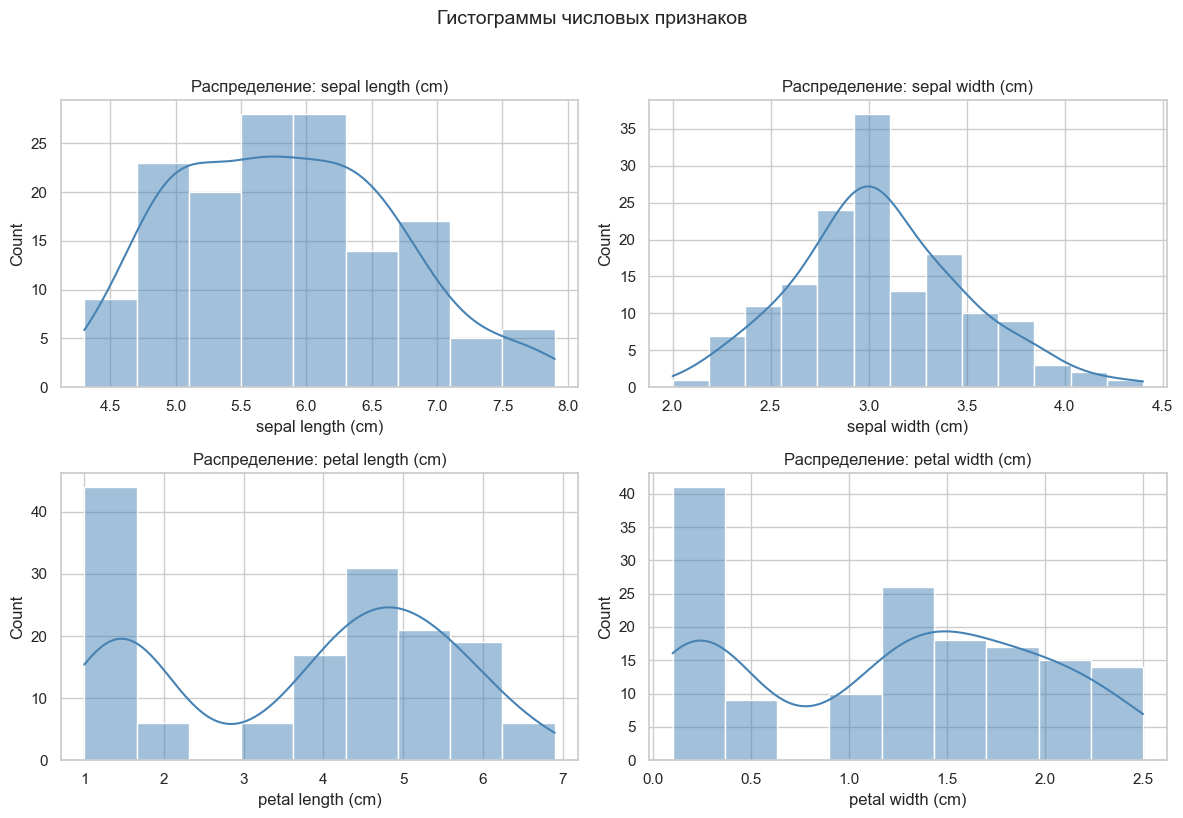

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Распределение: {col}')
plt.suptitle('Гистограммы числовых признаков', fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(ART / 'distributions.png', dpi=150, bbox_inches='tight')
plt.show()


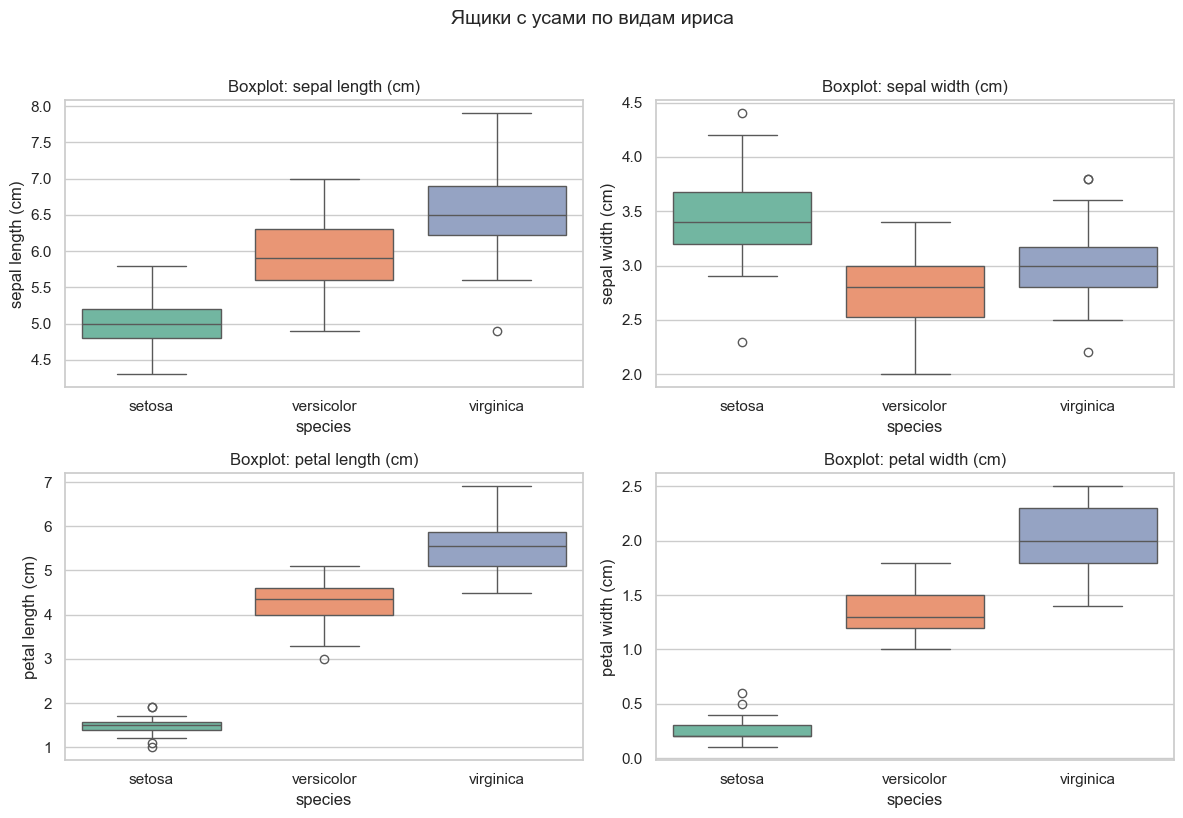

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()
for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='species', y=col, ax=axes[i], palette='Set2',
                order=['setosa', 'versicolor', 'virginica'])
    axes[i].set_title(f'Boxplot: {col}')
plt.suptitle('Ящики с усами по видам ириса', fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(ART / 'boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


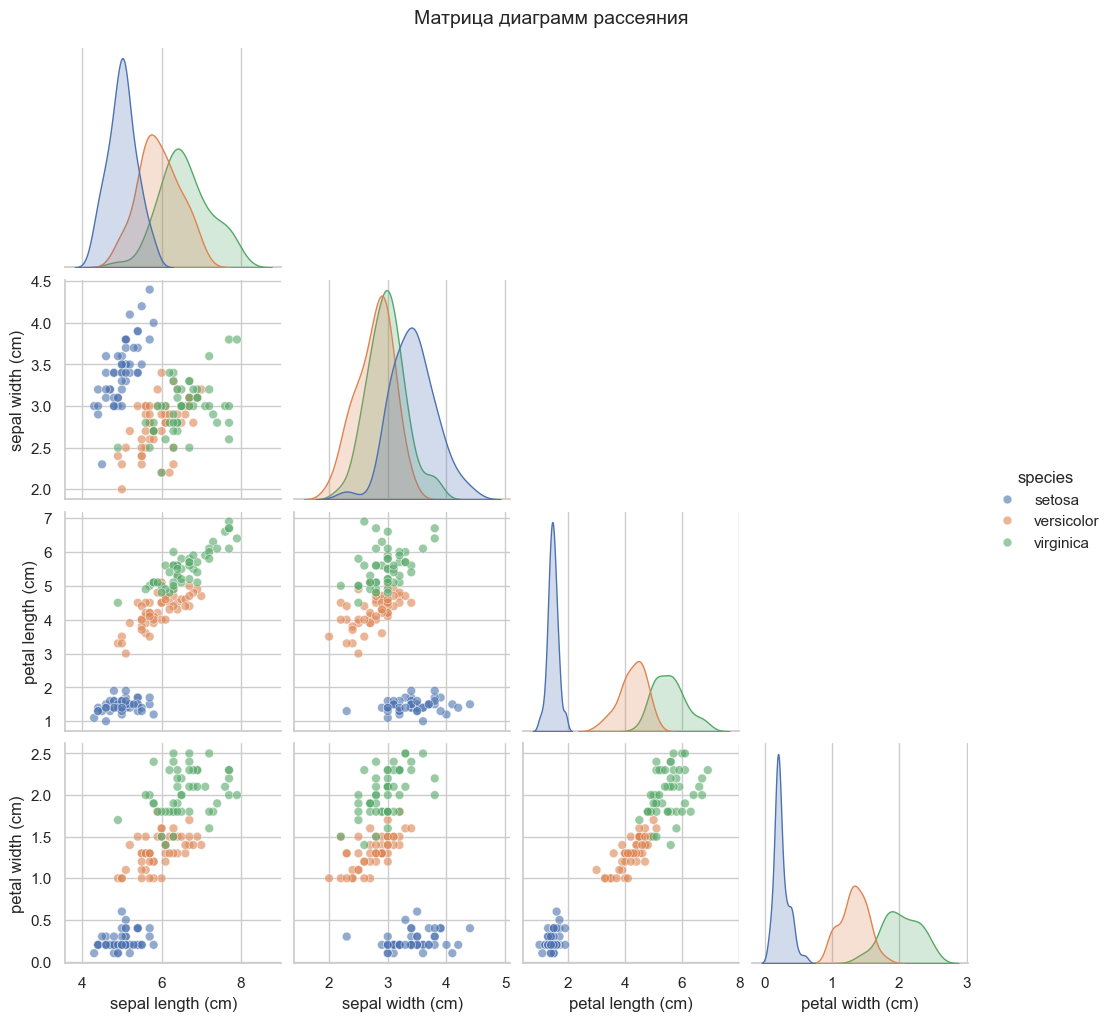

In [15]:
p = sns.pairplot(df, vars=num_cols, hue='species', corner=True,
                 plot_kws={'alpha': 0.6, 's': 40}, diag_kind='kde')
p.fig.suptitle('Матрица диаграмм рассеяния', y=1.02, fontsize=14)
p.savefig(ART / 'pairplot.png', dpi=150)
plt.show()


## 4. Корреляционный анализ
Коэффициент Пирсона: 1.0 — полная положительная, 0 — нет связи, −1 — полная отрицательная.


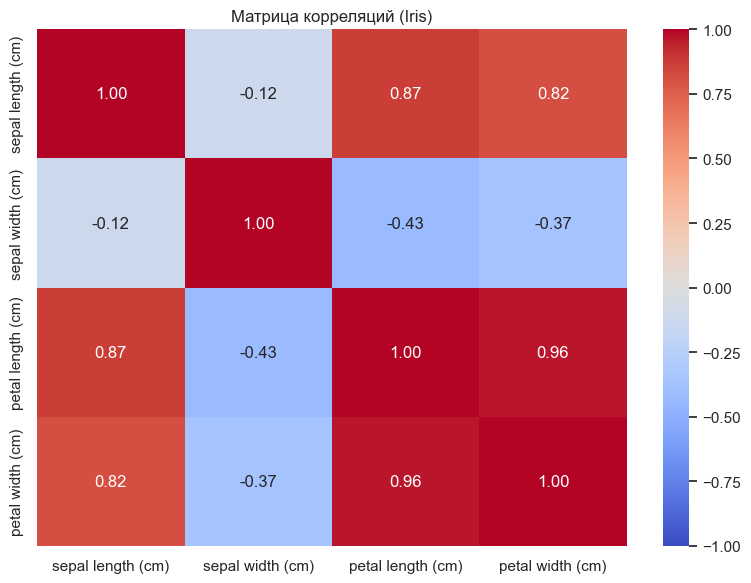

In [16]:
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
ax.set_title('Матрица корреляций (Iris)')
plt.tight_layout()
fig.savefig(ART / 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
corr.to_csv(ART / 'correlation_matrix.csv')


## Выводы
- Датасет сбалансирован (50 объектов на класс), пропусков нет.
- **petal length** и **petal width** — наиболее информативные признаки: большой разброс, чёткое разделение классов на boxplot и pairplot; **setosa** линейно отделима.
- Сильная корреляция petal length ↔ petal width (r ≈ 0.96) — мультиколлинеарность; при построении линейных моделей учитывать.
- **sepal width** наименее информативен — распределения классов сильно перекрываются.
